In [2]:
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset
import torchvision
import torchvision.models as models
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Task 1. Dataset selection and preparation

In [3]:
torch.manual_seed(42)

In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [5]:
full_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='trainval',  #всего 7349
    download=True,
    transform=transform
)

100%|██████████| 792M/792M [00:30<00:00, 25.9MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.0MB/s]


In [6]:
print(f"Number of images in Oxford Pets: {len(full_dataset)}")
print(f"Number of classes: {len(full_dataset.classes)}")

Number of images in Oxford Pets: 3680
Number of classes: 37


In [7]:
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
test_size = total_size - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

In [8]:
print(f"Train set: {len(train_dataset)} images")
print(f"Test set: {len(test_dataset)} images")

Train set: 2576 images
Test set: 1104 images


In [9]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
data_iter = iter(train_loader)
images, labels = next(data_iter)

In [11]:
print(f" The shape of one training batch:")
print(f"  images.shape = {images.shape}  # [batch_size, channels, height, width]")
print(f"  labels.shape = {labels.shape}")

 The shape of one training batch:
  images.shape = torch.Size([32, 3, 224, 224])  # [batch_size, channels, height, width]
  labels.shape = torch.Size([32])


# Task 2. Pretrained model loading

In [12]:
model = models.resnet18(pretrained=True)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 90.7MB/s]


In [13]:
print("Architecture of ResNet-18:\n")
print(model)

Architecture of ResNet-18:

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (

In [14]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total number of trainable parameters: {total_params:,}")

Total number of trainable parameters: 11,689,512


In [15]:
feature_extractor = torch.nn.Sequential(*list(model.children())[:-1])

In [16]:
classification_head = model.fc

In [17]:
print("\nFeature extractor (до avgpool включительно):")
print(feature_extractor)

print("\nClassification head (последний полносвязный слой):")
print(classification_head)


Feature extractor (до avgpool включительно):
Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     

# Task 3. Transfer learning with frozen backbone

In [18]:
for param in model.parameters():
    param.requires_grad = False


In [19]:
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 37)

In [20]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters after freezing: {trainable_params}")

Trainable parameters after freezing: 18981


In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [23]:
def train_one_epoch(loader, model, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [24]:
def evaluate(loader, model, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

In [25]:
# Сохраняем историю
train_losses, train_accs = [], []
test_losses, test_accs = [], []

In [26]:
for epoch in range(8):
    train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer)
    test_loss, test_acc = evaluate(test_loader, model, criterion)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)
    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Epoch 1: Train Loss: 2.2068, Train Acc: 0.5004 | Test Loss: 1.1716, Test Acc: 0.7663
Epoch 2: Train Loss: 0.9051, Train Acc: 0.8238 | Test Loss: 0.7187, Test Acc: 0.8442
Epoch 3: Train Loss: 0.5921, Train Acc: 0.8773 | Test Loss: 0.5976, Test Acc: 0.8587
Epoch 4: Train Loss: 0.4611, Train Acc: 0.9049 | Test Loss: 0.5059, Test Acc: 0.8641
Epoch 5: Train Loss: 0.3869, Train Acc: 0.9212 | Test Loss: 0.4898, Test Acc: 0.8750
Epoch 6: Train Loss: 0.3257, Train Acc: 0.9328 | Test Loss: 0.4333, Test Acc: 0.8886
Epoch 7: Train Loss: 0.2821, Train Acc: 0.9472 | Test Loss: 0.4256, Test Acc: 0.8841
Epoch 8: Train Loss: 0.2482, Train Acc: 0.9491 | Test Loss: 0.4121, Test Acc: 0.8832


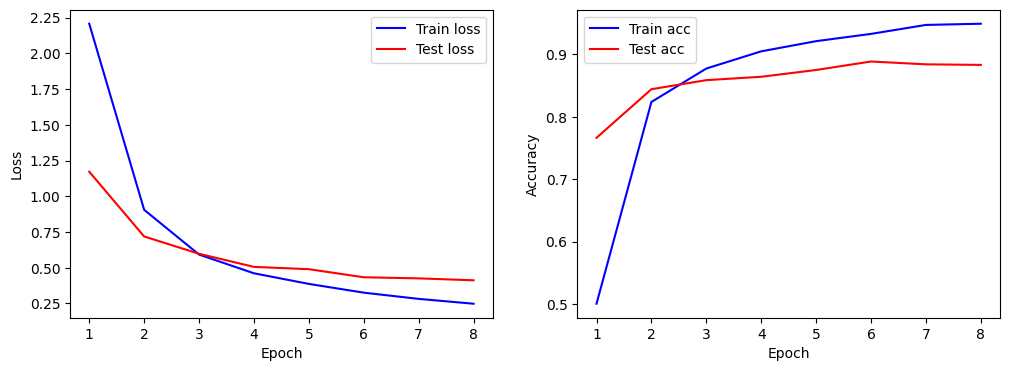

In [27]:
# Построение графиков
epochs = range(1, 9)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, 'b-', label='Train loss')
plt.plot(epochs, test_losses, 'r-', label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(epochs, train_accs, 'b-', label='Train acc')
plt.plot(epochs, test_accs, 'r-', label='Test acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [28]:
# Финальная тестовая точность
final_test_acc = test_accs[-1]
print(f"Final test accuracy (frozen backbone): {final_test_acc:.4f}")

Final test accuracy (frozen backbone): 0.8832


# Task 4. Fine-tuning

In [29]:
#Разморозка последнего блока (layer4)
for name, param in model.named_parameters():
    if 'layer4' in name:
        param.requires_grad = True

In [30]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

In [31]:
train_losses_ft, train_accs_ft = [], []
test_losses_ft, test_accs_ft = [], []

In [32]:
for epoch in range(5):
    train_loss, train_acc = train_one_epoch(train_loader, model, criterion, optimizer)
    test_loss, test_acc = evaluate(test_loader, model, criterion)
    train_losses_ft.append(train_loss)
    train_accs_ft.append(train_acc)
    test_losses_ft.append(test_loss)
    test_accs_ft.append(test_acc)
    print(f"Fine-tune Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Fine-tune Epoch 1: Train Loss: 0.2429, Train Acc: 0.9340 | Test Loss: 0.3443, Test Acc: 0.8804
Fine-tune Epoch 2: Train Loss: 0.0506, Train Acc: 0.9969 | Test Loss: 0.2993, Test Acc: 0.9058
Fine-tune Epoch 3: Train Loss: 0.0214, Train Acc: 1.0000 | Test Loss: 0.2999, Test Acc: 0.8967
Fine-tune Epoch 4: Train Loss: 0.0146, Train Acc: 0.9996 | Test Loss: 0.2989, Test Acc: 0.8995
Fine-tune Epoch 5: Train Loss: 0.0110, Train Acc: 0.9996 | Test Loss: 0.2999, Test Acc: 0.8967


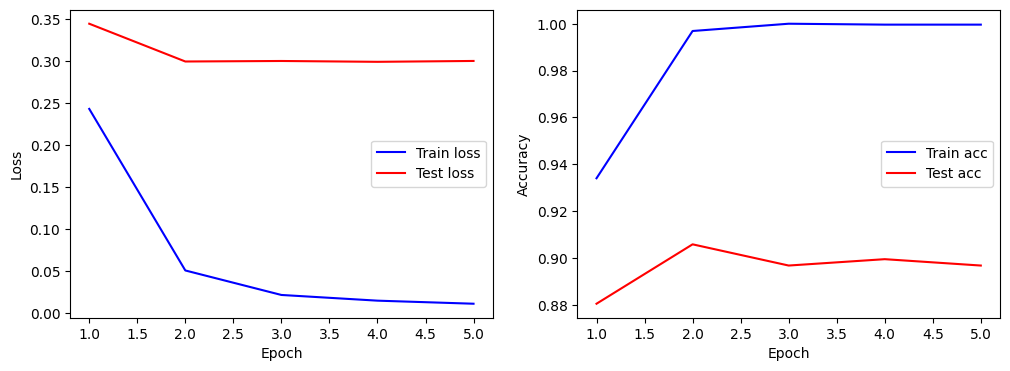

In [47]:
#Графики для fine-tuning
epochs_ft = range(1, 6)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(epochs_ft, train_losses_ft, 'b-', label='Train loss')
plt.plot(epochs_ft, test_losses_ft, 'r-', label='Test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1,2,2)
plt.plot(epochs_ft, train_accs_ft, 'b-', label='Train acc')
plt.plot(epochs_ft, test_accs_ft, 'r-', label='Test acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [48]:
final_test_acc_ft = test_accs_ft[-1]
print(f"Final test accuracy (fine-tuned): {final_test_acc_ft:.4f}")

Final test accuracy (fine-tuned): 0.8967


# Task 5. Metrics based evaluation

In [49]:
def compute_metrics(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    accuracy = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro')
    return accuracy, precision, recall, f1

In [50]:
#Для замороженной модели (Task 3)
acc_frozen, prec_frozen, rec_frozen, f1_frozen = compute_metrics(model, test_loader)

In [51]:
#Для fine-tuned модели (Task 4)
acc_ft, prec_ft, rec_ft, f1_ft = compute_metrics(model, test_loader)

In [52]:
#Создаём таблицу сравнения
data = {
    'Strategy': ['Frozen backbone', 'Fine-tuned'],
    'Accuracy': [acc_frozen, acc_ft],
    'Precision (macro)': [prec_frozen, prec_ft],
    'Recall (macro)': [rec_frozen, rec_ft],
    'F1 (macro)': [f1_frozen, f1_ft]
}
df = pd.DataFrame(data)
print(df)

          Strategy  Accuracy  Precision (macro)  Recall (macro)  F1 (macro)
0  Frozen backbone  0.896739           0.896592        0.898634    0.894965
1       Fine-tuned  0.896739           0.896592        0.898634    0.894965


# Task 6. Error analysis

In [53]:
best_model = model

In [54]:
best_model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = best_model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

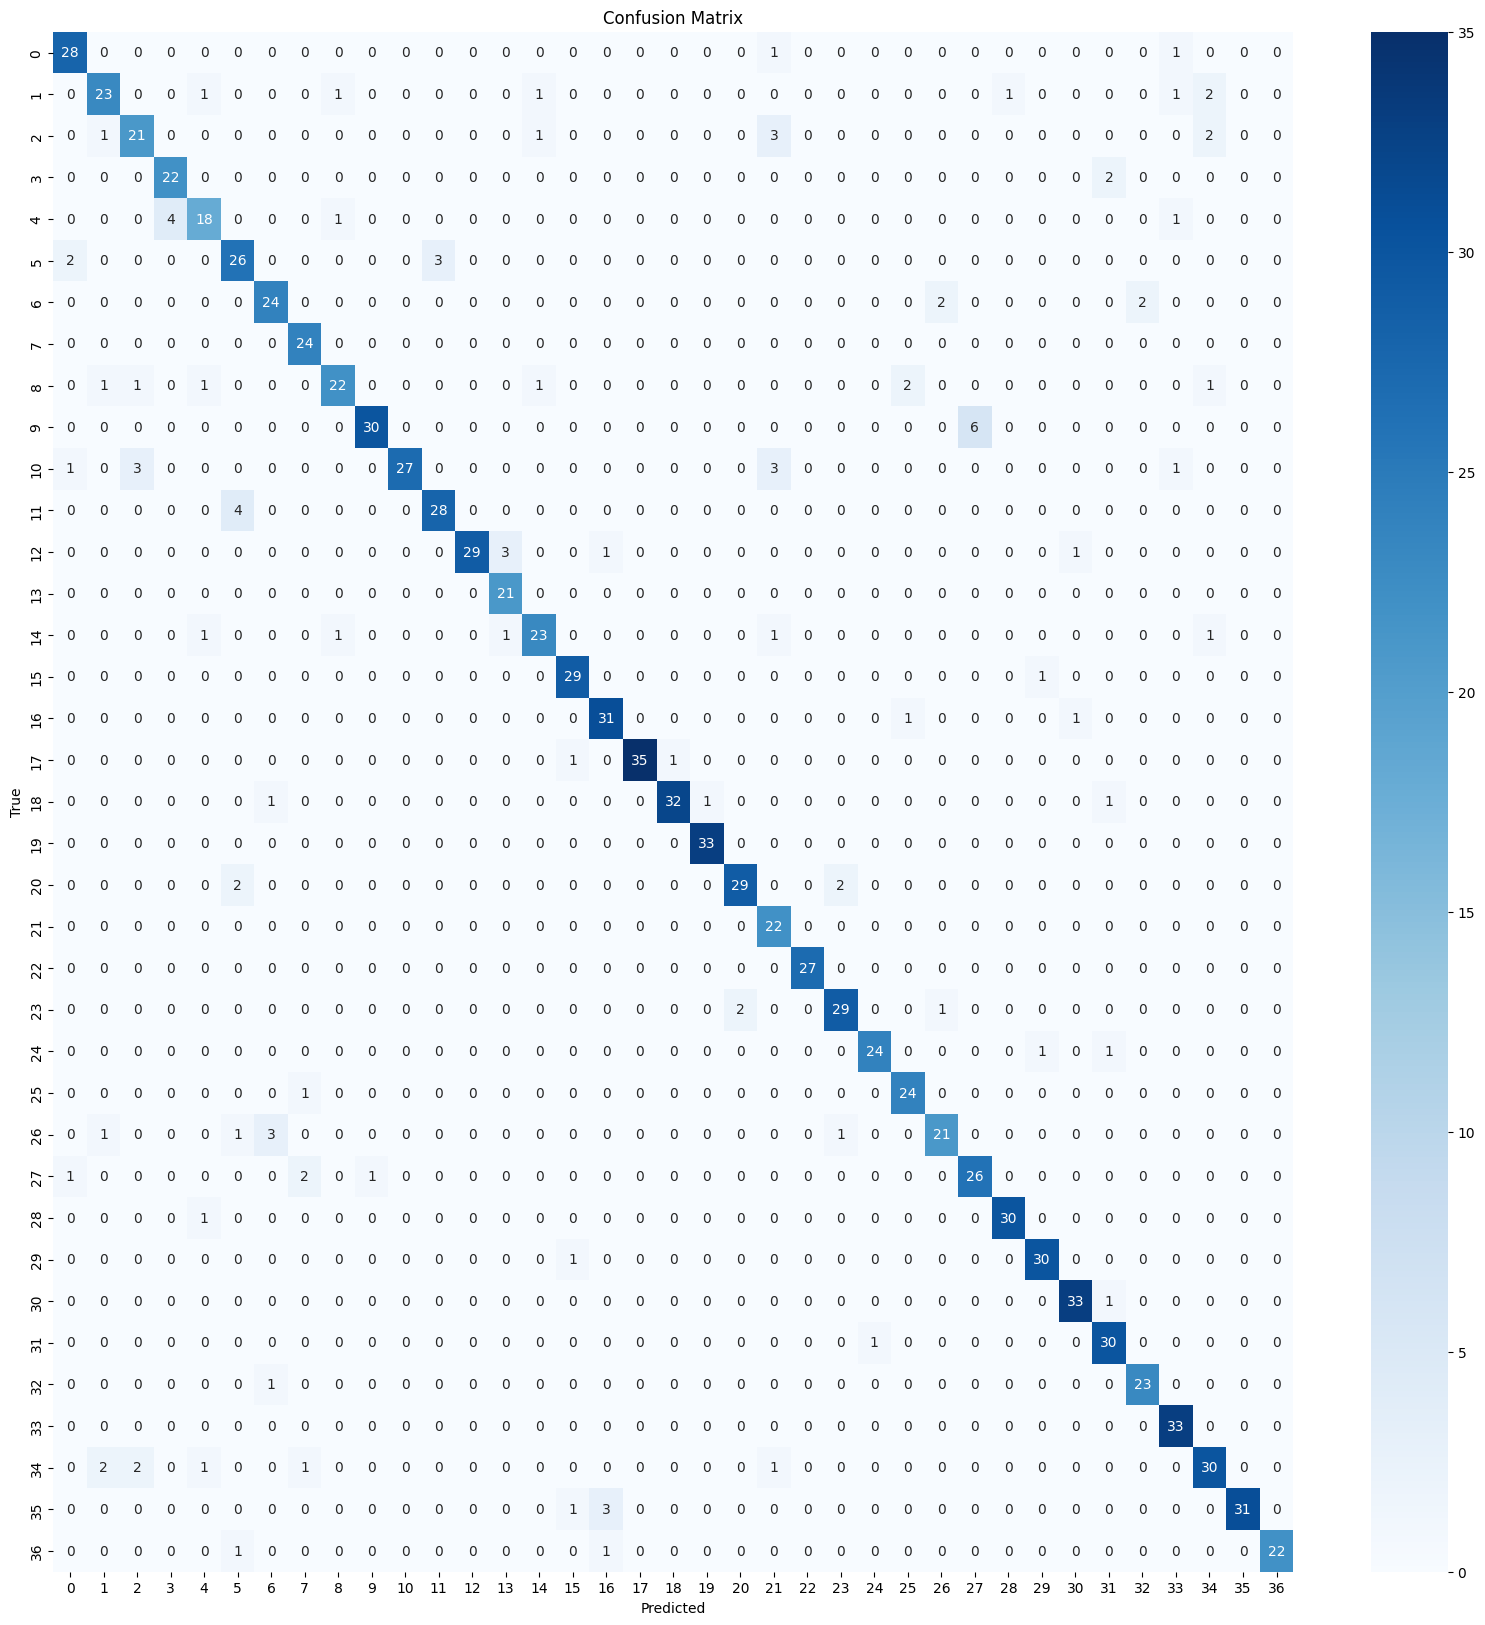

In [55]:
#Матрица ошибок
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(20,20))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(37), yticklabels=range(37))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [56]:
#Визуализация примеров
def imshow(img, title):
    img = img.numpy().transpose((1,2,0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')

In [57]:
#индексы правильно и неправильно классифицированных
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
correct_idx = np.where(all_preds == all_labels)[0]
wrong_idx = np.where(all_preds != all_labels)[0]

In [58]:
np.random.seed(42)
sample_correct = np.random.choice(correct_idx, 3, replace=False)
sample_wrong = np.random.choice(wrong_idx, 3, replace=False)

In [60]:
transform_display = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor()
])
test_dataset_display = datasets.OxfordIIITPet(root='./data', split='trainval', download=True, transform=transform_display)

In [61]:
test_indices = test_dataset.indices
test_subset_display = torch.utils.data.Subset(test_dataset_display, test_indices)

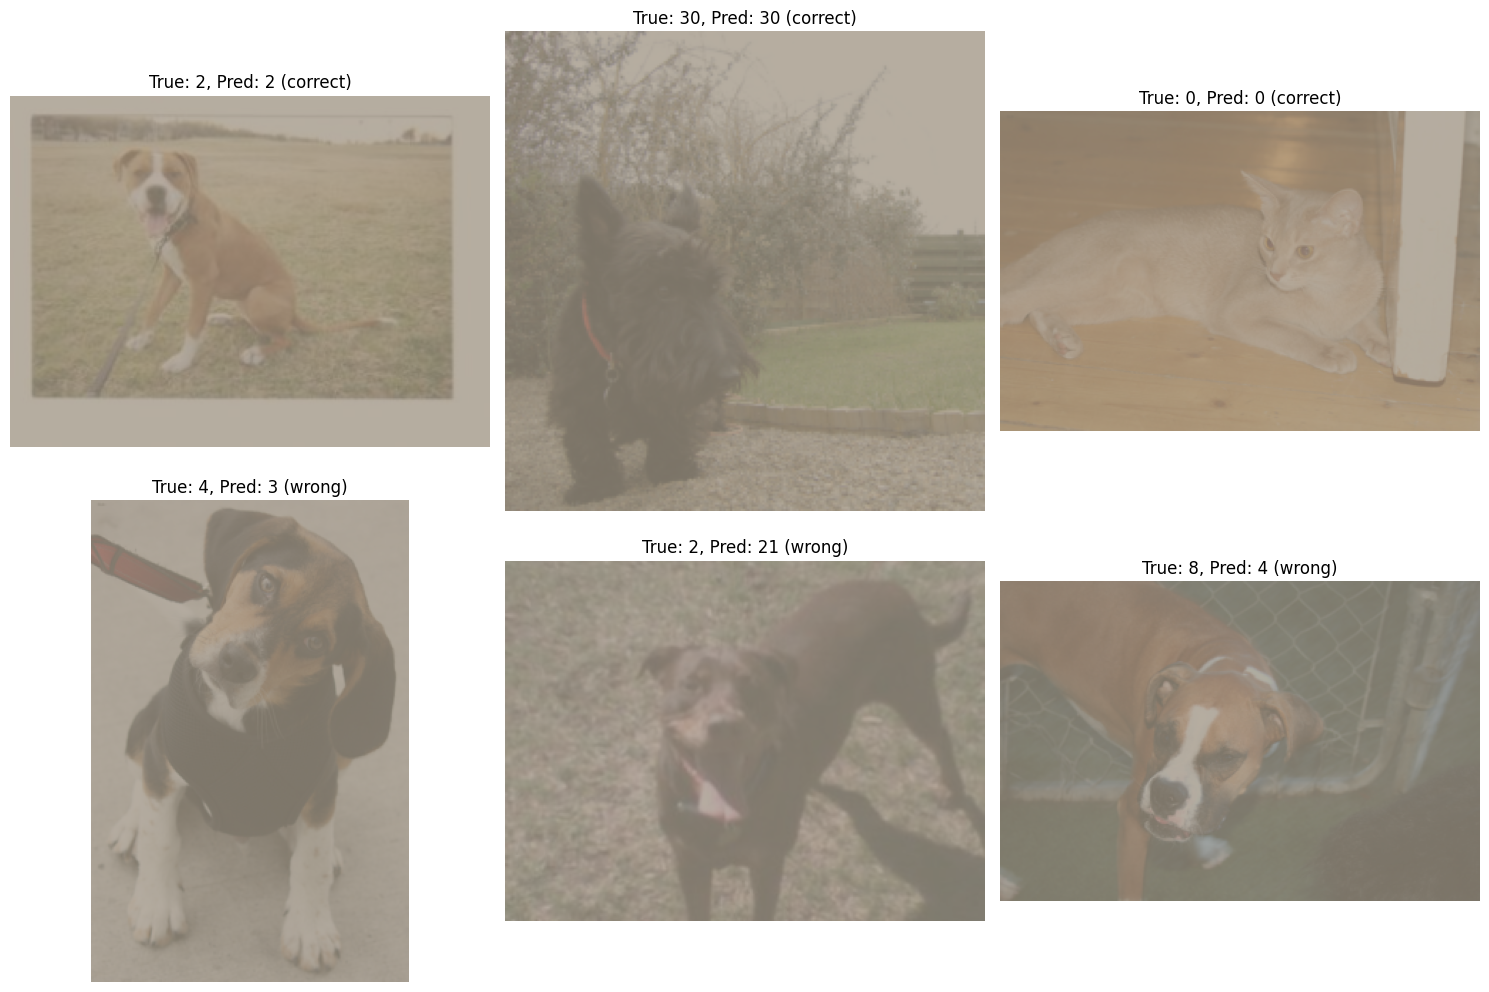

In [62]:
#картинки
plt.figure(figsize=(15,10))
for i, idx in enumerate(sample_correct):
    img, label = test_subset_display[idx]
    plt.subplot(2,3,i+1)
    imshow(img, f"True: {label}, Pred: {label} (correct)")
for i, idx in enumerate(sample_wrong):
    img, label = test_subset_display[idx]
    pred = all_preds[idx]
    plt.subplot(2,3,3+i+1)
    imshow(img, f"True: {label}, Pred: {pred} (wrong)")
plt.tight_layout()
plt.show()

# Task 7. Comparison with training from scratch

In [63]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=37):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [64]:
model_scratch = SimpleCNN(num_classes=37)
print(f"Trainable parameters (scratch): {sum(p.numel() for p in model_scratch.parameters())}")  #2.3 млн

Trainable parameters (scratch): 426085


In [66]:
# Обучение с нуля
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_scratch = model_scratch.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_scratch.parameters(), lr=0.001)

In [67]:
train_losses_s, train_accs_s = [], []
test_losses_s, test_accs_s = [], []

In [71]:
for epoch in range(8):
    train_loss, train_acc = train_one_epoch(train_loader, model_scratch, criterion, optimizer)
    test_loss, test_acc = evaluate(test_loader, model_scratch, criterion)
    train_losses_s.append(train_loss)
    train_accs_s.append(train_acc)
    test_losses_s.append(test_loss)
    test_accs_s.append(test_acc)
    print(f"Scratch Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.4f}")

Scratch Epoch 1: Train Loss: 2.8480, Train Acc: 0.1925 | Test Loss: 3.1823, Test Acc: 0.1350
Scratch Epoch 2: Train Loss: 2.7915, Train Acc: 0.2100 | Test Loss: 3.0821, Test Acc: 0.1513
Scratch Epoch 3: Train Loss: 2.7062, Train Acc: 0.2244 | Test Loss: 3.0556, Test Acc: 0.1495
Scratch Epoch 4: Train Loss: 2.6783, Train Acc: 0.2395 | Test Loss: 3.0460, Test Acc: 0.1558
Scratch Epoch 5: Train Loss: 2.5912, Train Acc: 0.2535 | Test Loss: 3.0355, Test Acc: 0.1721
Scratch Epoch 6: Train Loss: 2.5369, Train Acc: 0.2655 | Test Loss: 3.0080, Test Acc: 0.1757
Scratch Epoch 7: Train Loss: 2.4616, Train Acc: 0.2888 | Test Loss: 2.9557, Test Acc: 0.1839
Scratch Epoch 8: Train Loss: 2.3501, Train Acc: 0.3051 | Test Loss: 3.0204, Test Acc: 0.1821


In [72]:
final_acc_scratch = test_accs_s[-1]
print(f"Final test accuracy (from scratch): {final_acc_scratch:.4f}")

Final test accuracy (from scratch): 0.1821


In [73]:
#метрики для модели с нуля
acc_scratch, prec_scratch, rec_scratch, f1_scratch = compute_metrics(model_scratch, test_loader)

# Task 8. Feature representation analysis

In [74]:
sample_img, sample_label = test_dataset[0]  #(3,224,224)
sample_img = sample_img.unsqueeze(0).to(device)

In [75]:
activation = {}
def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

In [76]:
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [77]:
#pосле первого ReLU (model.relu)
handle1 = model.relu.register_forward_hook(get_activation('early'))

In [78]:
#выход layer4 (последнего блока)
handle2 = model.layer4.register_forward_hook(get_activation('deep'))

In [79]:
#Прямой проход
_ = model(sample_img)

In [80]:
#Убираем хуки
handle1.remove()
handle2.remove()

In [81]:
#Визуализация карт признаков
early_maps = activation['early'].squeeze(0).cpu().numpy()  # (64, 112, 112)
deep_maps = activation['deep'].squeeze(0).cpu().numpy()

In [82]:
#4 случайных канала
np.random.seed(42)
early_indices = np.random.choice(early_maps.shape[0], 4, replace=False)
deep_indices = np.random.choice(deep_maps.shape[0], 4, replace=False)

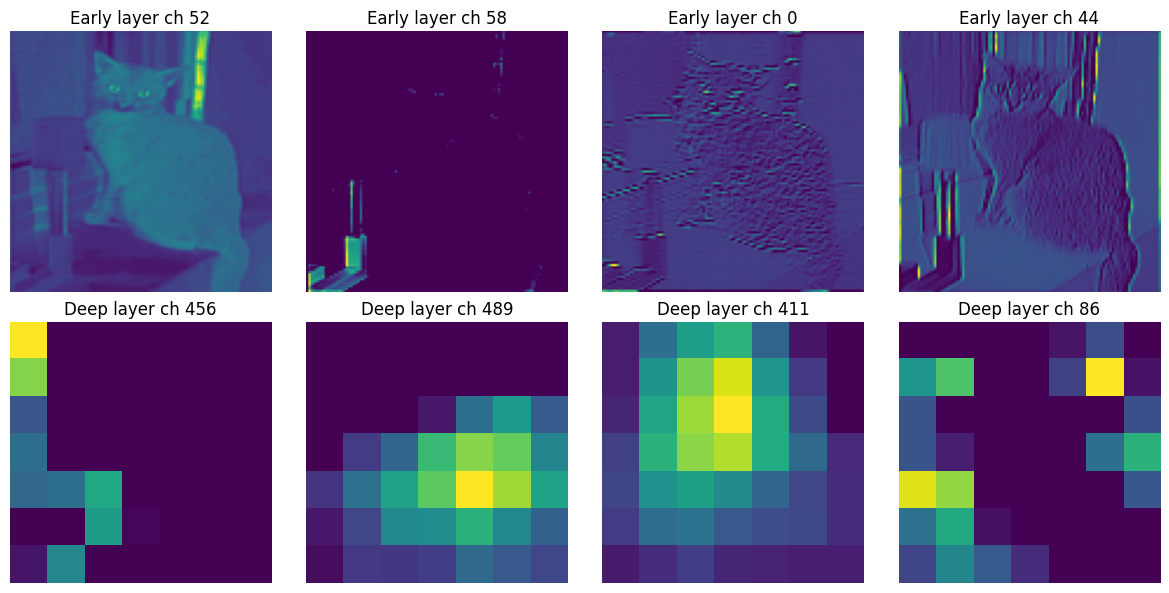

In [83]:
plt.figure(figsize=(12,6))
for i, idx in enumerate(early_indices):
    plt.subplot(2,4,i+1)
    plt.imshow(early_maps[idx], cmap='viridis')
    plt.title(f'Early layer ch {idx}')
    plt.axis('off')
for i, idx in enumerate(deep_indices):
    plt.subplot(2,4,4+i+1)
    plt.imshow(deep_maps[idx], cmap='viridis')
    plt.title(f'Deep layer ch {idx}')
    plt.axis('off')
plt.tight_layout()
plt.show()

# Task 9. Model efficiency analysis

In [84]:
def measure_epoch_time(model, loader, optimizer, criterion, epochs=1):
    model.train()
    start = time.time()
    for _ in range(epochs):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    end = time.time()
    return (end - start) / epochs

In [85]:
#fine-tuned— model
params_pretrained = sum(p.numel() for p in model.parameters() if p.requires_grad)
time_pretrained = measure_epoch_time(model, train_loader, optimizer, criterion)

In [88]:
#model_scratch
params_scratch = sum(p.numel() for p in model_scratch.parameters())
time_scratch = measure_epoch_time(model_scratch, train_loader, optimizer, criterion)

In [89]:
acc_pretrained = final_test_acc_ft
acc_scratch = final_acc_scratch

In [90]:
data_eff = {
    'Model': ['Pretrained (fine-tuned)', 'From scratch'],
    'Trainable params': [params_pretrained, params_scratch],
    'Time per epoch (s)': [time_pretrained, time_scratch],
    'Test accuracy': [acc_pretrained, acc_scratch]
}
df_eff = pd.DataFrame(data_eff)
print(df_eff)

                     Model  Trainable params  Time per epoch (s)  \
0  Pretrained (fine-tuned)           8412709          331.319535   
1             From scratch            426085          391.392359   

   Test accuracy  
0       0.896739  
1       0.182065  
